In [1]:
import discovery as ds
import jax
import discovery.samplers.numpyro as ds_numpyro
from matplotlib import pyplot as plt
import corner

In [2]:
psr = ds.Pulsar.read_feather("sim2.feather")

In [3]:
psr.noisedict

{}

In [5]:
signals = [
    psr.residuals,
    ds.makenoise_measurement_simple(psr, noisedict={"SIM2_log10_t2equad": -10}),
    ds.makegp_ecorr_simple(psr),
    ds.makegp_timing(psr),
]

In [6]:
psl = ds.PulsarLikelihood(signals)

In [7]:
p0 = ds.sample_uniform(psl.logL.params)
print(p0)

{'SIM1_efac': 1.471499098457482, 'SIM1_log10_ecorr': -7.668474966243116, 'SIM1_log10_t2equad': -6.237186567490888}


In [8]:
psl.logL(p0), jax.grad(psl.logL)(p0)

(Array(25180.44548859, dtype=float64),
 {'SIM1_efac': Array(-283.6539566, dtype=float64, weak_type=True),
  'SIM1_log10_ecorr': Array(0.76071353, dtype=float64, weak_type=True),
  'SIM1_log10_t2equad': Array(-206.12171092, dtype=float64, weak_type=True)})

In [8]:
npmodel = ds_numpyro.makemodel_transformed(psl.logL)
npsampler = ds_numpyro.makesampler_nuts(npmodel)

In [9]:
npsampler.run(jax.random.PRNGKey(101))

sample: 100%|██████████| 1536/1536 [09:05<00:00,  2.82it/s, 15 steps of size 3.33e-01. acc. prob=0.86]


In [10]:
chain = npsampler.to_df()

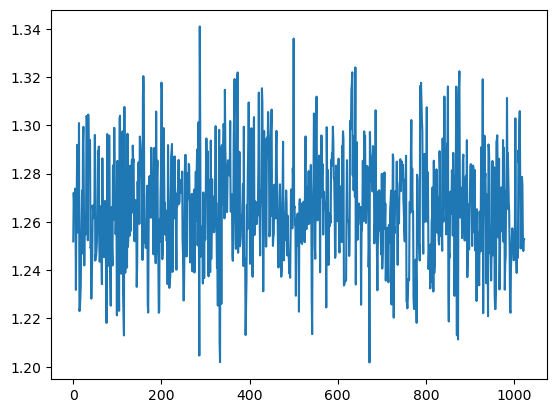

In [11]:
plt.plot(chain["SIM1_efac"].array)

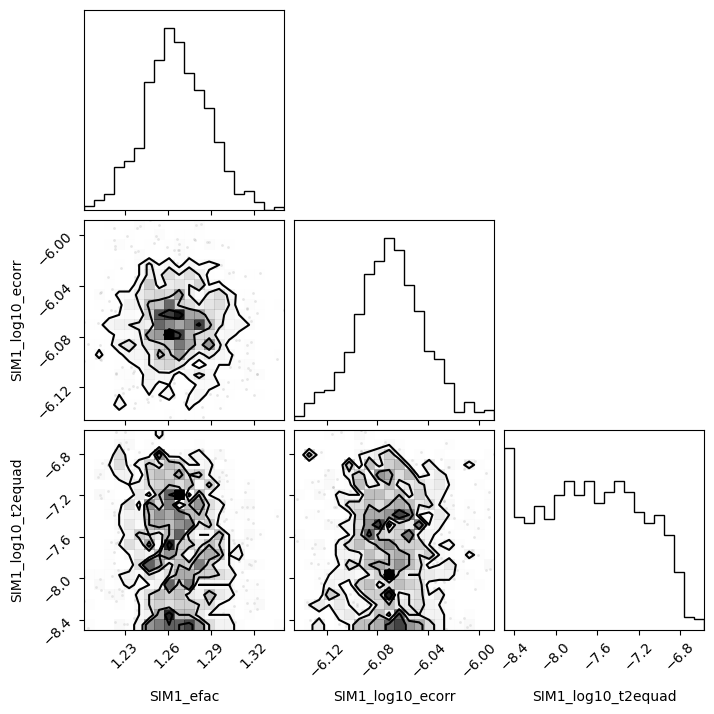

In [12]:
corner.corner(chain.to_numpy(), labels=psl.logL.params);